# WEEK 5 contest: baseline solution (MLP and a simple CNN)

**Task:** classify aerial / satellite images (256×256 px) into **20 scene classes**.

In order to start you need to download .zip file from Kaggle with all the folders organized for this contest. You can use this link, but remember it will be avialable only ~1 WEEK (don't forget to uncomment it).

In [6]:
!gdown 1sbnKeVmiOmT4ZZHIbXIxuBWF9CQLWt6s

Downloading...
From (original): https://drive.google.com/uc?id=1sbnKeVmiOmT4ZZHIbXIxuBWF9CQLWt6s
From (redirected): https://drive.google.com/uc?id=1sbnKeVmiOmT4ZZHIbXIxuBWF9CQLWt6s&confirm=t&uuid=8a8fc9cf-caa5-476d-abc3-39df52373913
To: /content/week-5-competition-geo-satellites-classification.zip
100% 305M/305M [00:04<00:00, 61.9MB/s]


Next we need to unzip our archive with subsets...

In [7]:
from IPython.display import clear_output

In [8]:
!unzip week-5-competition-geo-satellites-classification.zip
clear_output()

**The data**
```
train/  val/  test/          images, e.g. train/1000.jpg
train.csv, val.csv           id,label     (id = image file name, label = 0...19)
test.csv                     id           (the images you have to classify)
classes.csv                  label,class_name
sample_submission_example    example for the Kaggle submission
```
The training set is small (250 images per class) and the test set is larger, as in many real projects where
labelled data is expensive. The validation and test images come from the same distribution. Compare them carefully
with the training images.

**Plan of this notebook**
1. Setup
2. Read the CSV files
3. Transformations and augmentations with `transforms.Compose`
4. A `Dataset` that reads images from the folders
5. Training and evaluation functions
6. Model 1: MLP (with loss and accuracy graphs)
7. Model 2: a simple CNN (with loss and accuracy graphs)
8. Design your own CNN
9. Compare the models
10. Predict the test images and create `submission.csv`
11. Upload to Kaggle
12. **Assignment:** pretrained models and a confusion matrix

**Scoring:** Accuracy, the share of test images classified correctly. All classes have the same number of images,
so accuracy treats every class equally.

To run it with a GPU (Colab: *Runtime → Change runtime type → T4 GPU*).

## 1. Setup
Set `DATA_DIR` to the folder that contains `train/`, `val/`, `test/` and the CSV files
(on Kaggle: `/kaggle/input/<competition-name>`).

**Reproducibility (contest rule):** keep `SEED` fixed and call `seed_everything()` before training, so
re-running the notebook gives the same result.

In [9]:
import os
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

DATA_DIR = Path(os.environ.get("CONTEST_DATA", "/content/"))
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()
print("device:", DEVICE)
print("data folder:", sorted(p.name for p in DATA_DIR.iterdir()))

device: cpu
data folder: ['.config', 'classes.csv', 'sample_data', 'sample_submission_example.csv', 'test', 'test.csv', 'train', 'train.csv', 'val', 'val.csv', 'week-5-competition-geo-satellites-classification.zip']


## 2. Read the CSV files

In [10]:
train_table = pd.read_csv(DATA_DIR / "train.csv", dtype={"id": str})
val_table = pd.read_csv(DATA_DIR / "val.csv", dtype={"id": str})
test_table = pd.read_csv(DATA_DIR / "test.csv", dtype={"id": str})
classes = pd.read_csv(DATA_DIR / "classes.csv").sort_values("label").class_name.tolist()
NUM_CLASSES = len(classes)

print(f"train: {len(train_table)} images | val: {len(val_table)} | test: {len(test_table)} | classes: {NUM_CLASSES}")
print(classes)
train_table.head()

train: 4999 images | val: 699 | test: 8299 | classes: 20
['baseball_diamond', 'basketball_court', 'bridge', 'church', 'cloud', 'commercial_area', 'lake', 'medium_residential', 'overpass', 'palace', 'railway', 'railway_station', 'rectangular_farmland', 'roundabout', 'runway', 'sea_ice', 'snowberg', 'tennis_court', 'terrace', 'wetland']


,id,label
0,1.jpg,4
1,3.jpg,11
2,6.jpg,10
3,9.jpg,19
4,10.jpg,7


**Let's look at one training image per class.**

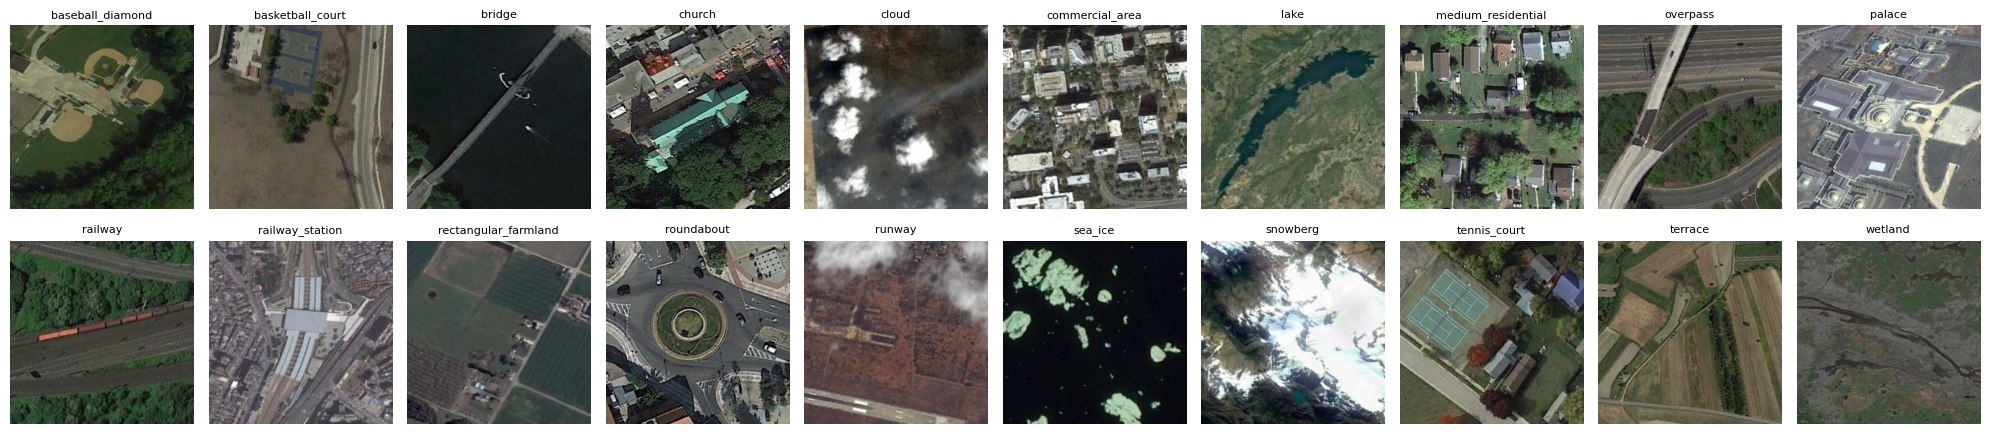

In [11]:
def image_file(folder, image_id):
    """Path of an image. Ids are file names such as '1000.jpg' (plain numbers also work)."""
    name = image_id if image_id.endswith(".jpg") else f"{image_id}.jpg"
    return DATA_DIR / folder / name

cols = (NUM_CLASSES + 1) // 2

fig, axes = plt.subplots(2, cols, figsize=(2 * cols, 4.6))
for label, ax in enumerate(axes.flat):
    ax.axis("off")
    if label < NUM_CLASSES:
        first_id = train_table[train_table.label == label].id.iloc[0]
        ax.imshow(Image.open(image_file("train", first_id)))
        ax.set_title(classes[label], fontsize=8)
plt.tight_layout(); plt.show()

## 3. Transformations and augmentations with `transforms.Compose`

As you might notice the **training set** is smaller comparing with the **test set**. Such cases we can overcome by the help of augmentations. In this lab we will go through some augmentation methods.

`transforms.Compose` contains several transformations; every image passes through them **in order**.

**Training images** get random augmentations, so the model sees a slightly different version of each image in
every epoch and can't simply memorise the training set. For aerial images these make sense:
* **flips and 90° rotations**: a photo taken from above has no "up" direction, so a rotated field is still a field;
* **brightness / contrast changes**: the same place looks different at different times of day.

**Validation and test images** are never augmented: they only get the same conversion to a tensor and the same
normalisation, so the model is evaluated on the images as they really are.

`ToTensor()` turns a picture into a tensor of shape (3, H, W) with values 0...1; `Normalize` then maps them to
about -1...1, which helps training.

In [12]:
IMG_SIZE = 32                                  # small images: fast, and enough for an MLP and a simple CNN
MEAN, STD = (0.5, 0.5, 0.5), (0.5, 0.5, 0.5)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),                          # mirror left-right, half of the images
    transforms.RandomVerticalFlip(p=0.5),                            # mirror top-bottom, half of the images
    transforms.RandomChoice([transforms.RandomRotation((angle, angle)) # rotate by 0, 90, 180 or 270 degrees
                             for angle in (0, 90, 180, 270)]),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),            # brightness and contrast x0.8 ... x1.2
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

eval_transform = transforms.Compose([         # validation and test: Remeber no augmentation for those parts!!!
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

print(train_transform)

Compose(
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.5)
    RandomChoice(
    RandomRotation(degrees=[0.0, 0.0], interpolation=nearest, expand=False, fill=0)
    RandomRotation(degrees=[90.0, 90.0], interpolation=nearest, expand=False, fill=0)
    RandomRotation(degrees=[180.0, 180.0], interpolation=nearest, expand=False, fill=0)
    RandomRotation(degrees=[270.0, 270.0], interpolation=nearest, expand=False, fill=0)
)(p=None)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
    ToTensor()
    Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
)


**What do the augmentations do?** A `Compose` is just a list of steps, so for the preview we can reuse every step
except `ToTensor` and `Normalize` (the last two), and show the same image six times.

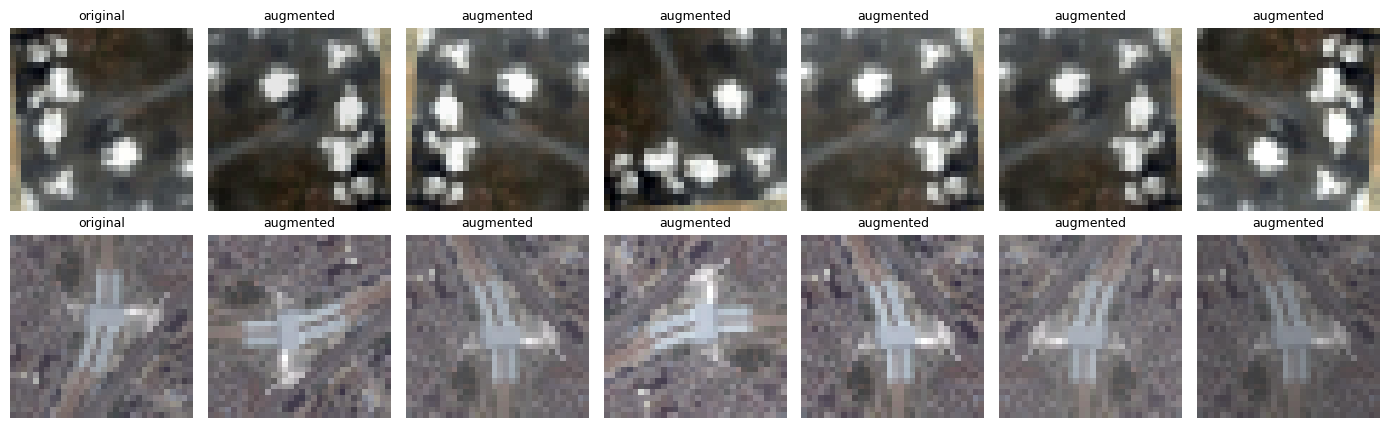

In [13]:
preview_transform = transforms.Compose(train_transform.transforms[:-2])   # augmentations only

fig, axes = plt.subplots(2, 7, figsize=(14, 4.4))
for row, image_id in enumerate(train_table.id.iloc[:2]):
    img = Image.open(image_file("train", image_id)).convert("RGB").resize((IMG_SIZE, IMG_SIZE), Image.BOX)
    axes[row, 0].imshow(img); axes[row, 0].set_title("original", fontsize=9)
    for col in range(1, 7):
        axes[row, col].imshow(preview_transform(img)); axes[row, col].set_title("augmented", fontsize=9)
for ax in axes.flat: ax.axis("off")
plt.tight_layout(); plt.show()

## 4. A `Dataset` that reads images from the folders
A PyTorch `Dataset` answers two questions: *how many samples are there?* (`__len__`) and *what is sample number i?*
(`__getitem__`). Ours reads the ids from a CSV file, loads each image from its folder **once** (resized to
`IMG_SIZE`, kept in memory so training is fast), and applies the transformation every time an image is requested,
so augmentations are different in every epoch.

The test CSV has no labels; for test images the dataset returns the label `-1`.

In [14]:
class ContestDataset(Dataset):
    def __init__(self, table, folder, transform, img_size=IMG_SIZE):
        self.ids = table.id.tolist()
        self.labels = table.label.tolist() if "label" in table.columns else [-1] * len(table)
        self.transform = transform
        self.images = []
        for image_id in tqdm(self.ids, desc=f"loading {folder}"):
            with Image.open(image_file(folder, image_id)) as img:
                self.images.append(img.convert("RGB").resize((img_size, img_size), Image.BOX))

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, i):
        return self.transform(self.images[i]), self.labels[i]

train_set = ContestDataset(train_table, "train", train_transform)
val_set = ContestDataset(val_table, "val", eval_transform)
test_set = ContestDataset(test_table, "test", eval_transform)

image, label = train_set[0]
print("one sample:", tuple(image.shape), "| label:", label, f"({classes[label]})")

loading train:   0%|          | 0/4999 [00:00<?, ?it/s]

loading val:   0%|          | 0/699 [00:00<?, ?it/s]

loading test:   0%|          | 0/8299 [00:00<?, ?it/s]

one sample: (3, 32, 32) | label: 4 (cloud)


## 5. Training and evaluation functions
The `DataLoader` groups samples into batches (and shuffles the training set). The same three functions are used for
every model in this notebook, including the pretrained ones in the assignment:

* `evaluate` computes the loss and the accuracy on a dataset (no training, no augmentation);
* `predict` returns the predicted class of every image in a dataset;
* `train_model` trains for a number of epochs. After every epoch it records the **loss** and **accuracy** on the
  training and the validation set, and at the end it goes back to the weights of the **best epoch** (highest
  validation accuracy).
* `make_loader` helps us to preserve order of images to keep reproducibility.

The models return raw scores (logits); `nn.CrossEntropyLoss` applies the softmax internally.

In [15]:
BATCH_SIZE = 64
criterion = nn.CrossEntropyLoss()

def make_loader(dataset, shuffle):
    generator = torch.Generator().manual_seed(SEED)     # fixed shuffling order -> reproducible
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=shuffle, generator=generator)

@torch.no_grad()
def evaluate(model, dataset):
    model.eval()
    total_loss, correct = 0.0, 0
    for images, labels in make_loader(dataset, shuffle=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        total_loss += criterion(outputs, labels).item() * len(images)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
    return total_loss / len(dataset), correct / len(dataset)

@torch.no_grad()
def predict(model, dataset):
    model.eval()
    predictions = []
    for images, _ in make_loader(dataset, shuffle=False):
        outputs = model(images.to(DEVICE))
        predictions.append(outputs.argmax(dim=1).cpu())
    return torch.cat(predictions).numpy()

def train_model(model, name, epochs=30, lr=1e-3):
    seed_everything()
    model = model.to(DEVICE)
    trainable = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.Adam(trainable, lr=lr)
    train_loader = make_loader(train_set, shuffle=True)

    history, best_acc, best_weights = [], -1.0, None    # -1.0 is just a number to compare with
    for epoch in range(1, epochs + 1):

        # training step (the same as we've learned so far for simpler models)
        model.train()
        total_loss, correct = 0.0, 0
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(images)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
        train_loss, train_acc = total_loss / len(train_set), correct / len(train_set)

        # validation step
        val_loss, val_acc = evaluate(model, val_set)
        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss,
                        "train_acc": train_acc, "val_acc": val_acc})

        if val_acc > best_acc:                                 # remember the best epoch and weights for it
            best_acc, best_weights = val_acc, copy.deepcopy(model.state_dict())
        if epoch == 1 or epoch % 5 == 0:
            print(f"{name} | epoch {epoch:2d} | train loss {train_loss:.3f} | val loss {val_loss:.3f} | "
                  f"train acc {train_acc:.3f} | val acc {val_acc:.3f}")

    model.load_state_dict(best_weights)                        # go back to the best epoch
    print(f"{name}: best validation accuracy {best_acc:.3f}")
    return pd.DataFrame(history)

def plot_history(history, name):
    """Loss (error) and accuracy per epoch, for the training and the validation set."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.epoch, history.train_loss, label="training")
    axes[0].plot(history.epoch, history.val_loss, label="validation")
    axes[0].set_title(f"{name}: loss (error)"); axes[0].set_xlabel("epoch"); axes[0].legend()
    axes[1].plot(history.epoch, history.train_acc, label="training")
    axes[1].plot(history.epoch, history.val_acc, label="validation")
    axes[1].set_title(f"{name}: accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend()
    plt.tight_layout(); plt.show()

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## 6. Model 1: MLP

Let's build a simple Multi-Layer Perceptron Layers. For that purpose we will use:
- `nn.Sequential()` is a very useful method when constructing complex mathematical systems like Neural Networks. Basically **torch.nn.Sequential** is an ordered container in PyTorch that chains modules (methods) together in a cascading fashion, where each module's output automatically serves as the input to the subsequent one.
- `nn.Linear` helps us to construct a classic fully-connected NN. This module applies a linear transformation to an input data. This is one of those module will be used with Sequential.
- `nn.Flatten()` turns every 3×32×32 image into a vector of 3,072 numbers, followed by two hidden layers.
The MLP treats every pixel as an independent number: in cotrast to a convolution, it has no idea which pixels are neighbours.

In [16]:
seed_everything()
mlp = nn.Sequential(
    nn.Flatten(),                                           # (3, 32, 32) -> 3072
    nn.Linear(3 * IMG_SIZE * IMG_SIZE, 512), nn.ReLU(), nn.Dropout(0.2),
    nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.2),
    nn.Linear(256, NUM_CLASSES),                            # one score per class
)
print(mlp)
print("trainable parameters:", count_parameters(mlp))

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=3072, out_features=512, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.2, inplace=False)
  (4): Linear(in_features=512, out_features=256, bias=True)
  (5): ReLU()
  (6): Dropout(p=0.2, inplace=False)
  (7): Linear(in_features=256, out_features=20, bias=True)
)
trainable parameters: 1709844


In [17]:
history_mlp = train_model(mlp, "MLP")

MLP | epoch  1 | train loss 2.842 | val loss 2.638 | train acc 0.105 | val acc 0.153
MLP | epoch  5 | train loss 2.435 | val loss 2.355 | train acc 0.229 | val acc 0.255
MLP | epoch 10 | train loss 2.319 | val loss 2.256 | train acc 0.262 | val acc 0.300
MLP | epoch 15 | train loss 2.246 | val loss 2.150 | train acc 0.295 | val acc 0.310
MLP | epoch 20 | train loss 2.170 | val loss 2.111 | train acc 0.316 | val acc 0.325
MLP | epoch 25 | train loss 2.140 | val loss 2.090 | train acc 0.321 | val acc 0.340
MLP | epoch 30 | train loss 2.066 | val loss 2.055 | train acc 0.336 | val acc 0.335
MLP: best validation accuracy 0.356


**Loss and accuracy of the MLP.** Training images are augmented and validation images are not, so the two curves
are not directly comparable. Still, if the training loss keeps falling while the validation loss rises, the model
is starting to memorise the training images (overfitting).

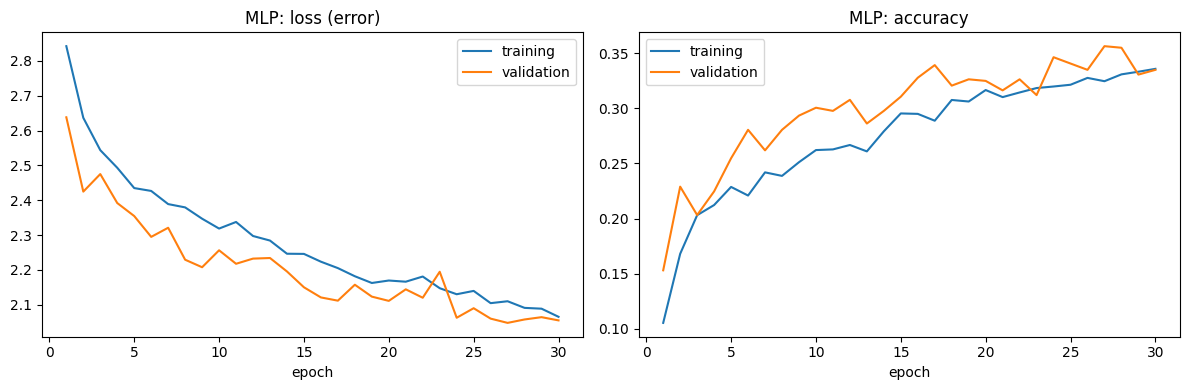

In [18]:
plot_history(history_mlp, "MLP")

## 7. Model 2: a simple CNN

Now let's build a small CNN:


*   `nn.Conv2d` with only one 3×3 convolution layer. Suck block could help to look at small  neighbourhoods of pixels, so the network can learn local patterns (edges, roofs, roads, field boundaries) wherever they appear in the image.
* `MaxPool2d(2)` halves the image size: 32 → 16. Take a guess why we need that?
* `nn.Linear`- based classifier then makes the decision.

In [19]:
seed_everything()
cnn = nn.Sequential(
    # feature extraction
    nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(),   # (3, 32, 32)  -> (32, 32, 32)
    nn.MaxPool2d(2),                                         # (32, 32, 32) -> (32, 16, 16)
    # classification
    nn.Flatten(),                                            # (32, 16, 16) -> 32 * 16 * 16 = 8192
    nn.Linear(32 * (IMG_SIZE // 2) ** 2, 128), nn.ReLU(),
    nn.Linear(128, NUM_CLASSES),
)
print(cnn)
print("trainable parameters:", count_parameters(cnn))

Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Flatten(start_dim=1, end_dim=-1)
  (4): Linear(in_features=8192, out_features=128, bias=True)
  (5): ReLU()
  (6): Linear(in_features=128, out_features=20, bias=True)
)
trainable parameters: 1052180


In [20]:
history_cnn = train_model(cnn, "CNN")

CNN | epoch  1 | train loss 2.739 | val loss 2.435 | train acc 0.141 | val acc 0.246
CNN | epoch  5 | train loss 1.963 | val loss 1.902 | train acc 0.356 | val acc 0.389
CNN | epoch 10 | train loss 1.741 | val loss 1.707 | train acc 0.442 | val acc 0.458
CNN | epoch 15 | train loss 1.562 | val loss 1.602 | train acc 0.498 | val acc 0.512
CNN | epoch 20 | train loss 1.460 | val loss 1.483 | train acc 0.529 | val acc 0.539
CNN | epoch 25 | train loss 1.372 | val loss 1.440 | train acc 0.562 | val acc 0.549
CNN | epoch 30 | train loss 1.301 | val loss 1.427 | train acc 0.580 | val acc 0.549
CNN: best validation accuracy 0.549


**Loss and accuracy of the CNN.** Compare them with the MLP graphs above.

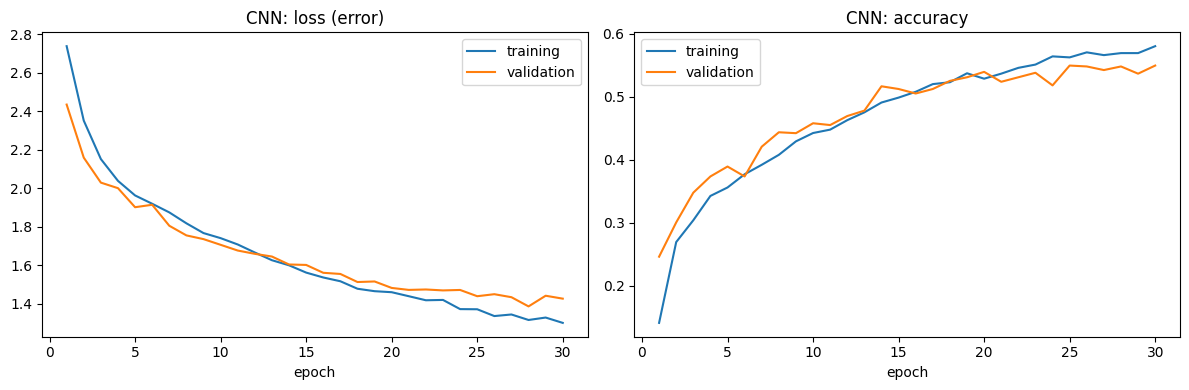

In [21]:
plot_history(history_cnn, "CNN")

## 8. Compare the models
Note that the CNN has **fewer parameters** than the MLP, but still it performs much better, even with only one convolution layer.

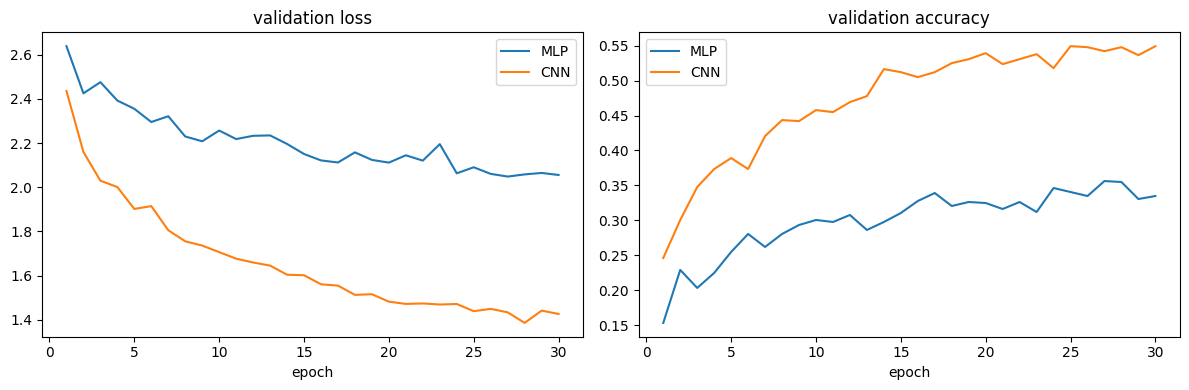

model  parameters  best val accuracy
  MLP     1709844              0.356
  CNN     1052180              0.549


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for history, name in [(history_mlp, "MLP"), (history_cnn, "CNN")]:
    axes[0].plot(history.epoch, history.val_loss, label=name)
    axes[1].plot(history.epoch, history.val_acc, label=name)
axes[0].set_title("validation loss"); axes[1].set_title("validation accuracy")
for ax in axes: ax.set_xlabel("epoch"); ax.legend()
plt.tight_layout(); plt.show()

results = pd.DataFrame({
    "model": ["MLP", "CNN"],
    "parameters": [count_parameters(mlp), count_parameters(cnn)],
    "best val accuracy": [history_mlp.val_acc.max(), history_cnn.val_acc.max()],
})
print(results.round(3).to_string(index=False))

Take your time and make experiments with different combinations and design your own CNN. Don't forget to use such technics as:

- [Dropout](https://docs.pytorch.org/docs/2.14/generated/torch.nn.modules.dropout.Dropout.html#dropout$0)
- [Batch normalization](https://docs.pytorch.org/docs/2.14/generated/torch.nn.BatchNorm2d.html)

Also don't forget to add more convolution layers as it allows to construct more and more complex features for your model.

In [23]:
# ** YOUR CODE **
# advanced_cnn = nn.Sequential(
#     # feature extraction
#     # classification
# )

## 9. Predict the test images and create `submission.csv`
It's up to you what model to use for the submission. We use the model with the best validation accuracy. The submission needs one row per test image: the `id` exactly
as in `test.csv` (e.g. `1000.jpg`) and the predicted `label`.

In [24]:
best_name = results.sort_values("best val accuracy").model.iloc[-1]
best_model = {"MLP": mlp, "CNN": cnn}[best_name]

submission = pd.DataFrame({"id": test_set.ids, "label": predict(best_model, test_set)})

# format check before uploading
assert list(submission.columns) == ["id", "label"]
assert submission.id.tolist() == test_table.id.tolist()
assert submission.label.between(0, NUM_CLASSES - 1).all()

submission.to_csv("submission.csv", index=False)
print("model used:", best_name, "| rows:", len(submission))
submission.head()

model used: CNN | rows: 8299


,id,label
0,2.jpg,4
1,4.jpg,5
2,5.jpg,9
3,7.jpg,18
4,8.jpg,7


## 10. Upload to Kaggle
Download `submission.csv` to your own computer (Colab: the cell below; Kaggle notebook: the *Output* panel) and
upload it on the competition page with *Submit Prediction* (will be opened on **Saturday 3th of October**).


---
## 11. Assignment: pretrained models and a confusion matrix

Networks pretrained on ImageNet (1.2 million photos, 1,000 classes) have already learned general visual features:
edges, textures, shapes. We can reuse them and train only a small part for our 20 classes.

**Allowed architectures** (no Transformers and no other families):

| Family | torchvision constructors | Final layer to replace |
|---|---|---|
| AlexNet | `alexnet` | `model.classifier` (last layer: `model.classifier[6]`) |
| VGG | `vgg11`, `vgg13`, `vgg16`, `vgg19` (also `_bn` versions) | `model.classifier` (last layer: `model.classifier[6]`) |
| Inception | `googlenet`, `inception_v3` | `model.fc` |
| ResNet | `resnet18`, `resnet34`, `resnet50`, `resnet101`, `resnet152` | `model.fc` |

### Example: how to prepare a pretrained model
The example below only **prepares** a pretrained ResNet-18. It shows four steps:
1. load the model with pretrained weights;
2. **freeze** all its weights (`requires_grad = False`), so training doesn't change them;
3. **unfreeze** the last block (`requires_grad = True`), so it can adapt to aerial images;
4. remove the original 1,000-class classifier and combine the network with **our own classifier** using `nn.Sequential`.

In [25]:
# 1) load ResNet-18 with weights pretrained on ImageNet
backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
print(backbone)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 58.3MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [26]:
# 2) freeze all pretrained weights
for param in backbone.parameters():
    param.requires_grad = False

# 3) unfreeze the last residual block, so it can be retrained
for param in backbone.layer4.parameters():
    param.requires_grad = True

# check which parts will be trained
for name, param in backbone.named_parameters():
    if param.requires_grad:
        print("trainable:", name)

trainable: layer4.0.conv1.weight
trainable: layer4.0.bn1.weight
trainable: layer4.0.bn1.bias
trainable: layer4.0.conv2.weight
trainable: layer4.0.bn2.weight
trainable: layer4.0.bn2.bias
trainable: layer4.0.downsample.0.weight
trainable: layer4.0.downsample.1.weight
trainable: layer4.0.downsample.1.bias
trainable: layer4.1.conv1.weight
trainable: layer4.1.bn1.weight
trainable: layer4.1.bn1.bias
trainable: layer4.1.conv2.weight
trainable: layer4.1.bn2.weight
trainable: layer4.1.bn2.bias


In [27]:
# 4) replace the original classifier by our own and combine both with nn.Sequential
num_features = backbone.fc.in_features          # 512 for ResNet-18
backbone.fc = nn.Identity()                     # the backbone now outputs 512 features per image

classifier = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.LeakyReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, NUM_CLASSES),                # no softmax: nn.CrossEntropyLoss applies it
)

pretrained_model = nn.Sequential(backbone, classifier)

print(classifier)
print("trainable parameters:", count_parameters(pretrained_model),
      "of", sum(p.numel() for p in pretrained_model.parameters()))

# quick check: a batch of 2 images of size 224x224 gives 2 x 20 class scores
print("output shape:", tuple(pretrained_model(torch.randn(2, 3, 224, 224)).shape))

Sequential(
  (0): Linear(in_features=512, out_features=256, bias=True)
  (1): LeakyReLU(negative_slope=0.01)
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=256, out_features=20, bias=True)
)
trainable parameters: 8530196 of 11312980
output shape: (2, 20)


### Your tasks
1. **Train a pretrained model** from the allowed list. Prepare it as in the example (your own classifier combined
   with `nn.Sequential`, at least one pretrained layer or block unfrozen) and train it with `train_model`.
2. **Adapt the data pipeline.** Pretrained models expect larger images and ImageNet normalisation: think about
   `IMG_SIZE` (e.g. 128 or 224; `inception_v3` needs 299), `Normalize` with ImageNet mean and std, and which
   augmentations help. You'll need new `transforms.Compose` pipelines and new `ContestDataset` objects.
3. **Compare** your pretrained model with the MLP and the Advanced CNN you have designed previously: a table of validation accuracy and the loss and
   accuracy graphs (`plot_history`).
4. **Confusion matrix.** Make a confusion matrix of your best model on the validation set (rows = true class,
   columns = predicted class, with class names on the axes). Which classes are confused most often, and why might
   that be? Look at a few of the misclassified images.
   *Hint:* `predict(model, val_set)` gives the predictions, `val_set.labels` the true classes;
   see `sklearn.metrics.confusion_matrix` and `ConfusionMatrixDisplay`. But it's up to you how to implement it.
5. **Experiment and explain:** which layers to unfreeze, learning rate, augmentations, image size. Which change had the biggest effect on the validation accuracy, and why?
6. **Submit** your best model to Kaggle with a short description of what it is.

**Requirements**
* Only AlexNet, VGG, Inception (GoogLeNet / Inception v3) and ResNet; no Transformers, no other architectures.
* Pretrained weights only from torchvision (ImageNet).
* Your own classification layers, combined with the pretrained network via `nn.Sequential`.
* No external data; the notebook runs end to end with a fixed `SEED` and reproduces your score.

In [28]:
# *** YOUR CODE ***